<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path=kagglehub.dataset_download("yasserh/titanic-dataset")
path

Using Colab cache for faster access to the 'titanic-dataset' dataset.


'/kaggle/input/titanic-dataset'

In [5]:
import os
os.listdir(path)

['Titanic-Dataset.csv']

In [7]:
df=pd.read_csv(path+"/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.shape


(891, 12)

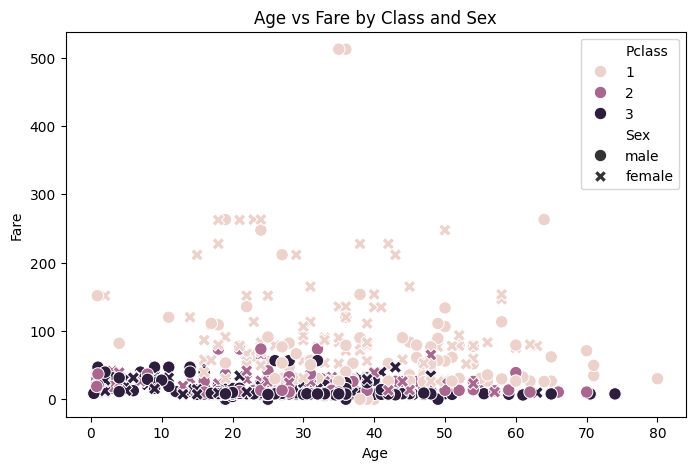

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Pclass",
    style="Sex",
    s=80
)
plt.title("Age vs Fare by Class and Sex")
plt.show()

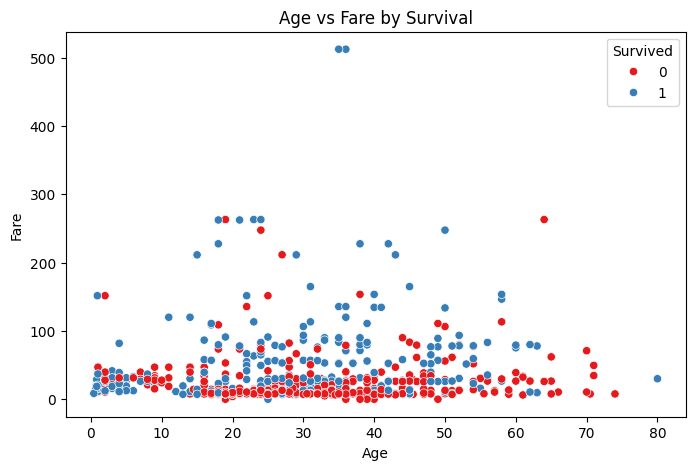

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived",
    palette="Set1"
)
plt.title("Age vs Fare by Survival")
plt.show()

In [19]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
83,84,0,1,"Carrau, Mr. Francisco M",male,28.0,0,0,113059,47.1000,NaN,S
625,626,0,1,"Sutton, Mr. Frederick",male,61.0,0,0,36963,32.3208,D50,S
212,213,0,3,"Perkin, Mr. John Henry",male,22.0,0,0,A/5 21174,7.2500,NaN,S
704,705,0,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
565,566,0,3,"Davies, Mr. Alfred J",male,24.0,2,0,A/4 48871,24.1500,NaN,S


In [46]:
df.drop('Cabin',axis=1,inplace=True)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,r2_score
from sklearn.impute import SimpleImputer

In [48]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('Survived',axis=1),df['Survived'],test_size=0.2,random_state=42)

In [49]:
imp=SimpleImputer(strategy='mean')
x_train['Age']=imp.fit_transform(x_train[['Age']])
x_test['Age']=imp.transform(x_test[['Age']])

In [50]:

imp2 = SimpleImputer(strategy='most_frequent')

x_train['Embarked'] = imp2.fit_transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = imp2.transform(x_test[['Embarked']]).ravel()

In [55]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Name      712 non-null    object 
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Ticket    712 non-null    object 
 7   Fare      712 non-null    float64
 8   Embarked  712 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 55.6+ KB


In [56]:
scale=StandardScaler()
x_train[['Age','Fare']]=scale.fit_transform(x_train[['Age','Fare']])
x_test[['Age','Fare']]=scale.transform(x_test[['Age','Fare']])

In [57]:
x_train.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
331,1,"Partner, Mr. Austen",male,1.232263,0,0,113043,-0.078684,S
733,2,"Berriman, Mr. William John",male,-0.500482,0,0,28425,-0.377145,S
382,3,"Tikkanen, Mr. Juho",male,0.192616,0,0,STON/O 2. 3101293,-0.474867,S
704,3,"Hansen, Mr. Henrik Juul",male,-0.269449,1,0,350025,-0.476230,S
813,3,"Andersson, Miss. Ebba Iris Alfrida",female,-1.809667,4,2,347082,-0.025249,S


In [61]:
ohe=OneHotEncoder(drop='first',sparse_output=False)
x_train_cat=ohe.fit_transform(x_train[['Sex','Embarked']])
x_test_cat=ohe.transform(x_test[['Sex','Embarked']])

In [62]:
x_train_trf=np.concatenate((x_train[['Age','Fare','Pclass','SibSp','Parch',]].values,x_train_cat),axis=1)
x_test_trf=np.concatenate((x_test[['Age','Fare','Pclass','SibSp','Parch',]].values,x_test_cat),axis=1)

In [65]:
x_train_trf.shape,x_test_trf.shape

((712, 8), (179, 8))

In [69]:
model = LogisticRegression()
model.fit(x_train_trf, y_train)

LogisticRegression()

In [70]:
y_pred = model.predict(x_test_trf)

In [85]:
model.coef_,model.intercept_

(array([[-0.40130785,  0.13045561, -0.93992021, -0.29513995, -0.10979031,
         -2.58999753, -0.09598615, -0.40636873]]),
 array([3.73353499]))

In [71]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [74]:
Lr=LinearRegression()
Lr.fit(x_train_trf,y_train)

LinearRegression()

In [75]:
y_pred_lr=Lr.predict(x_test_trf)

In [79]:
r2_score(y_test,y_pred_lr)

0.44325872737930205

In [80]:
confusion_matrix(y_test,y_pred)

array([[90, 15],
       [19, 55]])

In [81]:
def gd(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5

    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])

    return weights[1:],weights[0]

def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [82]:
coef_,intercept_ = gd(x_train_trf,y_train)

In [87]:
coef_,intercept_

(array([-0.41543148,  0.1212156 , -0.97593962, -0.30619628, -0.12861171,
        -2.72360545, -0.14903193, -0.44196095]),
 np.float64(3.9387789490830296))

In [83]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [84]:
m,b

(np.float64(3.427211467521818), np.float64(-32.493995032607884))

In [98]:
X = x_train[['Age', 'Fare']]
y = y_train

In [99]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()
model2.fit(X, y)

LogisticRegression()

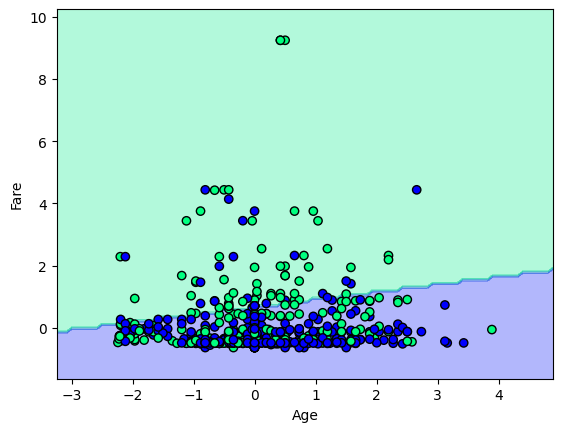

In [100]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

DecisionBoundaryDisplay.from_estimator(
    model2,
    X,
    response_method="predict",
    cmap="winter",
    alpha=0.3
)

plt.scatter(
    X['Age'],
    X['Fare'],
    c=y,
    cmap='winter',
    edgecolor='k'
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()